# Лабораторная работа №5 — Классификация

В этом задании дан датасет с реальными данными одной строительной компании о бронированиях на покупку недвижимости. 

Бронирование может привести к заключению договора на покупку, а может быть отменено. 
Для планирования своих финансовых показателей компания хочет прогнозировать, приведет ли бронирование к заключению договора или нет. Таким образом, вам предстоит построить модель для бинарной классификации бронирований.

В этом задании будем работать только с жилой недвижимостью, поскольку именно по ней имеется больше всего данных.

In [327]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import f1_score, precision_score, recall_score

## 1. Загрузите данные из файла "база.csv".

Столбцы (признаки) имеют следующий смысл:
* a. УИД_Брони – уникальный идентификатор брони (для классификации его использовать не надо – это просто id)
* b. ДатаБрони – дата установления брони
* c. ВремяБрони – время установления брони (GMT+4)
* d. ИсточникБрони – способ оформления брони: МП — мобильное приложение, ручная — офис продаж (бинарный признак)
* e. ВременнаяБронь – подтвержденная заявка на бронь(«Нет») или заявка на бронь не подтверждена отделом продаж («Да») (бинарный признак)
* f. СледующийСтатус – если пусто или «В резерве» — статус еще не определен, «Продана» — договор оформлен, «Свободна» — бронь снята(отменена). Это и есть целевой признак, который нужно научиться предсказывать
* g. Город – город проекта
* h. ВидПомещения – один из 4 видов: жилые помещения, нежилые помещения, кладовые, паркинг. Нас будут интересовать бронирования только со значением этого признака «жилые помещения».
* i. Тип – количество комнат для жилых помещений (для остальных видов неактуально)
* j. ПродаваемаяПлощадь – общая продаваемая площадь помещения
* k. Этаж – этаж расположения помещения
* l. СтоимостьНаДатуБрони – актуальная стоимость по прайсу на дату установления брони
* m. ТипСтоимости – «Стоимость при 100% оплате» или «Стоимость в рассрочку», остальные варианты можно считать отсутствием значения (бинарный признак)
* n. ВариантОплаты – «Единовременная оплата» или «Оплата в рассрочку» (бинарный признак)
* o. ВариантОплатыДоп – уточненный вариант оплаты: Ипотека/Вторичное жилье, если "пусто" — использовать ВариантОплатыp. 
* p. СкидкаНаКвартиру – размер предоставленной скидки при её наличии, отрицательное значение — это наценка на помещение (как правило, при выводе из закрытого ассортимента)
* q. ФактическаяСтоимостьПомещения – стоимость заключения сделки (стоимость на дату брони за вычетом скидки)
* r. СделкаАН – участие в сделке агентства недвижимости (да/нет) (бинарный признак)
* s. ИнвестиционныйПродукт – да/нет — признак продажи помещения по инвестиционному договору (бинарный признак)
* t. Привилегия – да/нет — признак продажи помещения по инвестиционному договору типа Привилегия (бинарный признак)
* u. Статус лида (из CRM) – Статус клиента: S - успешный, P - в работе, F - забракованный

In [ ]:
df = pd.read_csv('data/База.csv', encoding='windows-1251', sep=';')
df.head()

,УИД_Брони,ДатаБрони,ВремяБрони,ИсточникБрони,ВременнаяБронь,СледующийСтатус,Город,ВидПомещения,Тип,ПродаваемаяПлощадь,...,СтоимостьНаДатуБрони,ТипСтоимости,ВариантОплаты,ВариантОплатыДоп,СкидкаНаКвартиру,ФактическаяСтоимостьПомещения,СделкаАН,ИнвестиционныйПродукт,Привилегия,Статус лида (из CRM)
0,d192173f-fc14-11eb-9512-000c29ad50ac,13.08.2021,1:00:01,ручная,Да,Свободна,Ярославль,жилые помещения,"2,5к",72,...,4296100,Стоимость при 100% оплате,Единовременная оплата,NaN,NaN,4296100,Нет,Нет,Нет,S
1,43574a1f-fe8b-11eb-9512-000c29ad50ac,16.08.2021,4:12:46,ручная,Да,Свободна,Ярославль,жилые помещения,"3,5к","79,8",...,5279600,Стоимость при 100% оплате,Единовременная оплата,NaN,NaN,5279600,Да,Нет,Нет,F
2,0e7b7a81-fe97-11eb-9512-000c29ad50ac,16.08.2021,5:37:12,ручная,Да,Свободна,Ярославль,жилые помещения,"2,5к","65,4",...,4201400,Стоимость при 100% оплате,Единовременная оплата,NaN,NaN,4201400,Нет,Нет,Нет,S
3,c7041428-f90b-11eb-9512-000c29ad50ac,09.08.2021,4:17:35,ручная,Да,Свободна,Тюмень,жилые помещения,"2,5к","61,6",...,5414500,Стоимость при 100% оплате,Единовременная оплата,NaN,NaN,5414500,Нет,Нет,Нет,S
4,60090518-fe8b-11eb-9512-000c29ad50ac,16.08.2021,4:13:35,ручная,Да,Свободна,Ярославль,жилые помещения,"2,5к","65,4",...,4201400,Стоимость при 100% оплате,Единовременная оплата,NaN,NaN,4201400,Нет,Нет,Нет,P


In [329]:
print(df.shape)

(5519, 21)


In [330]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5519 entries, 0 to 5518
Data columns (total 21 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   УИД_Брони                      5519 non-null   object 
 1   ДатаБрони                      5519 non-null   object 
 2   ВремяБрони                     5519 non-null   object 
 3   ИсточникБрони                  5519 non-null   object 
 4   ВременнаяБронь                 5519 non-null   object 
 5   СледующийСтатус                5411 non-null   object 
 6   Город                          5512 non-null   object 
 7   ВидПомещения                   5427 non-null   object 
 8   Тип                            5320 non-null   object 
 9   ПродаваемаяПлощадь             5318 non-null   object 
 10  Этаж                           4771 non-null   float64
 11  СтоимостьНаДатуБрони           5519 non-null   object 
 12  ТипСтоимости                   5519 non-null   o

## 2. Предварительная фильтрация

Поскольку нас интересуют только сделки с жилой недвижимостью,
отфильтруйте данные, оставив только те, для которых «ВидПомещения» =
«жилые помещения». В дальнейшем этот столбец использоваться не будет,
его можно удалить (или удалите его из датасета вообще, или просто нигде
далее не рассматривайте).

In [331]:
df = df[df['ВидПомещения'] == 'жилые помещения'].copy()
df.drop(columns=['ВидПомещения'], inplace=True)

Также для нас бесполезны данные, по которым статус не определен.
Отфильтруйте данные по признаку «СледующийСтатус». В оставшихся
строчках замените значение «Продана» на 1, «Свободна» – на 0.

In [332]:
df['СледующийСтатус'].value_counts()

СледующийСтатус
Свободна     2804
Продана      1140
В резерве      76
Name: count, dtype: int64

In [333]:
df = df[df['СледующийСтатус'].isin(['Продана', 'Свободна'])].copy()
df['СледующийСтатус'] = df['СледующийСтатус'].map({'Продана': 1, 'Свободна': 0})

In [334]:
df['СледующийСтатус'].value_counts()

СледующийСтатус
0    2804
1    1140
Name: count, dtype: int64

Не забывайте, что столбец «УИД_Брони» для нас также не представляет
интереса – удалите его из датасета вообще, или просто нигде далее не
рассматривайте.

In [335]:
df.drop(columns=['УИД_Брони'], inplace=True)

## 3. Проверьте тип данных и преобразуйте все данные к числовому типу.

Для тех полей, которые по смыслу являются числовыми (например,
«ПродаваемаяПлощадь») – просто проверьте правильность типа.

In [336]:
df.head(5)

,ДатаБрони,ВремяБрони,ИсточникБрони,ВременнаяБронь,СледующийСтатус,Город,Тип,ПродаваемаяПлощадь,Этаж,СтоимостьНаДатуБрони,ТипСтоимости,ВариантОплаты,ВариантОплатыДоп,СкидкаНаКвартиру,ФактическаяСтоимостьПомещения,СделкаАН,ИнвестиционныйПродукт,Привилегия,Статус лида (из CRM)
0,13.08.2021,1:00:01,ручная,Да,0,Ярославль,"2,5к",72,3.0,4296100,Стоимость при 100% оплате,Единовременная оплата,NaN,NaN,4296100,Нет,Нет,Нет,S
1,16.08.2021,4:12:46,ручная,Да,0,Ярославль,"3,5к","79,8",2.0,5279600,Стоимость при 100% оплате,Единовременная оплата,NaN,NaN,5279600,Да,Нет,Нет,F
2,16.08.2021,5:37:12,ручная,Да,0,Ярославль,"2,5к","65,4",18.0,4201400,Стоимость при 100% оплате,Единовременная оплата,NaN,NaN,4201400,Нет,Нет,Нет,S
3,09.08.2021,4:17:35,ручная,Да,0,Тюмень,"2,5к","61,6",12.0,5414500,Стоимость при 100% оплате,Единовременная оплата,NaN,NaN,5414500,Нет,Нет,Нет,S
4,16.08.2021,4:13:35,ручная,Да,0,Ярославль,"2,5к","65,4",18.0,4201400,Стоимость при 100% оплате,Единовременная оплата,NaN,NaN,4201400,Нет,Нет,Нет,P


In [337]:
# Числовые с запятой как разделителем
for col in ['ПродаваемаяПлощадь', 'СтоимостьНаДатуБрони', 'СкидкаНаКвартиру', 'ФактическаяСтоимостьПомещения']:
    df[col] = df[col].astype(str).str.replace(',', '.', regex=False)
    df[col] = pd.to_numeric(df[col], errors='coerce') #если значение не удаётся преобразовать в число (например, пустая строка или 'nan'), вместо ошибки подставляет NaN

Для бинарных признаков (например, «ИсточникБрони») выполните
кодирование (один вариант закодируйте 0, другой 1).

In [338]:
df['ИсточникБрони'].value_counts()

ИсточникБрони
МП        2500
ручная    1444
Name: count, dtype: int64

In [339]:
df['ВременнаяБронь'].value_counts()

ВременнаяБронь
Нет    2759
Да     1185
Name: count, dtype: int64

In [340]:
df['ТипСтоимости'].value_counts()

ТипСтоимости
Стоимость при 100% оплате    3887
Стоимость в рассрочку          57
Name: count, dtype: int64

In [341]:
df['ВариантОплаты'].value_counts()

ВариантОплаты
Единовременная оплата    3480
Оплата в рассрочку        461
Name: count, dtype: int64

In [342]:
df['СделкаАН'].value_counts()

СделкаАН
Нет    2303
Да     1641
Name: count, dtype: int64

In [343]:
df['ИнвестиционныйПродукт'].value_counts()

ИнвестиционныйПродукт
Нет    3837
Да      107
Name: count, dtype: int64

In [344]:
df['Привилегия'].value_counts()

Привилегия
Нет    3857
Да       87
Name: count, dtype: int64

In [345]:
df['ИсточникБрони'] = df['ИсточникБрони'].map({'МП': 1, 'ручная': 0})
df['ВременнаяБронь'] = df['ВременнаяБронь'].map({'Да': 1, 'Нет': 0})
df['ТипСтоимости'] = df['ТипСтоимости'].map({'Стоимость при 100% оплате': 0, 'Стоимость в рассрочку': 1})
df['ВариантОплаты'] = df['ВариантОплаты'].map({'Единовременная оплата': 0, 'Оплата в рассрочку': 1})
df['СделкаАН'] = df['СделкаАН'].map({'Да': 1, 'Нет': 0})
df['ИнвестиционныйПродукт'] = df['ИнвестиционныйПродукт'].map({'Да': 1, 'Нет': 0})
df['Привилегия'] = df['Привилегия'].map({'Да': 1, 'Нет': 0})


Для категориальных не бинарных признаков (например, «Город»)
выполните one-hot кодирование.

In [346]:
df = pd.get_dummies(df, columns=['Город', 'Статус лида (из CRM)'])

Обратите внимание на поле «Тип». По смыслу оно числовое (количество
комнат), но напрямую сконвертировать его в числовой тип мешает буковка
«к» в конце. Напишите вручную преобразование, которое удаляет букву «к»
в конце и конвертирует то, что осталось, в число. Если это невозможно
(среди данных вам встретится еще вариант, когда в этом поле записано
просто «с») – просто пока оставьте поле пустым (NaN).

In [347]:
def parse_type(val):
    if pd.isna(val):
        return np.nan
    s = str(val).strip().replace(',', '.')
    if s.endswith('к'):
        s = s[:-1]
    try:
        return float(s)
    except ValueError:  # сюда попадает 'с' и любое другое нечисловое
        return np.nan

df['Тип'] = df['Тип'].apply(parse_type)
print(df['Тип'].value_counts())

Тип
2.5    1082
1.5     796
1.0     653
2.0     496
3.5     453
3.0     227
4.5      28
4.0       6
Name: count, dtype: int64


Также особо нужно рассмотреть поля «ДатаБрони» и «ВремяБрони». Их
можно либо просто преобразовать в число (это проще всего, но наименее
полезно), либо выделить из них отдельные характеристики (например,
месяц, время суток и т.п.).

In [348]:
# Дата и время
df['ДатаБрони'] = pd.to_datetime(df['ДатаБрони'], dayfirst=True, errors='coerce')
df['МесяцБрони'] = df['ДатаБрони'].dt.month
df['ДеньНедели'] = df['ДатаБрони'].dt.dayofweek
df.drop(columns=['ДатаБрони'], inplace=True)

df['ВремяБрони'] = pd.to_datetime(df['ВремяБрони'], format='%H:%M:%S', errors='coerce')
df['ЧасБрони'] = df['ВремяБрони'].dt.hour
df.drop(columns=['ВремяБрони'], inplace=True)

In [349]:
df.dtypes

ИсточникБрони                      int64
ВременнаяБронь                     int64
СледующийСтатус                    int64
Тип                              float64
ПродаваемаяПлощадь               float64
Этаж                             float64
СтоимостьНаДатуБрони             float64
ТипСтоимости                       int64
ВариантОплаты                    float64
ВариантОплатыДоп                  object
СкидкаНаКвартиру                 float64
ФактическаяСтоимостьПомещения    float64
СделкаАН                           int64
ИнвестиционныйПродукт              int64
Привилегия                         int64
Город_Ижевск                        bool
Город_Набережные Челны              bool
Город_Пермь                         bool
Город_Сочи                          bool
Город_Тверь                         bool
Город_Тюмень                        bool
Город_Уфа                           bool
Город_Хабаровск                     bool
Город_Ярославль                     bool
Статус лида (из 

In [350]:
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

## 4. Проверьте, есть ли по каким-либо признакам отсутствующие данные.

In [351]:
print(df.isnull().sum())

ИсточникБрони                       0
ВременнаяБронь                      0
СледующийСтатус                     0
Тип                               203
ПродаваемаяПлощадь                 44
Этаж                                0
СтоимостьНаДатуБрони                0
ТипСтоимости                        0
ВариантОплаты                       3
ВариантОплатыДоп                 1726
СкидкаНаКвартиру                 3246
ФактическаяСтоимостьПомещения       0
СделкаАН                            0
ИнвестиционныйПродукт               0
Привилегия                          0
Город_Ижевск                        0
Город_Набережные Челны              0
Город_Пермь                         0
Город_Сочи                          0
Город_Тверь                         0
Город_Тюмень                        0
Город_Уфа                           0
Город_Хабаровск                     0
Город_Ярославль                     0
Статус лида (из CRM)_F              0
Статус лида (из CRM)_P              0
Статус лида 

Отсутствующие данные в поле «СкидкаНаКвартиру» замените на 0 (это
значение по умолчанию – если поле не заполнено, то скидки, по всей
видимости, нет).

In [352]:
df['СкидкаНаКвартиру'] = df['СкидкаНаКвартиру'].fillna(0)

Отсутствующие данные в полях «Тип» и «ПродаваемаяПлощадь» замените
на медианное значение, вычисленное по всему набору данных (признаки
кажутся достаточно важными, поэтому удалять эти столбцы не хочется;
пустых значений довольно много, поэтому удалять строки тоже не очень
хорошо; какого-то значения «по умолчанию» для этих полей нет; поэтому
заменить эти значения на медиану представляется наилучшим решением).

In [353]:
df['Тип'] = df['Тип'].fillna(df['Тип'].median())
df['ПродаваемаяПлощадь'] = df['ПродаваемаяПлощадь'].fillna(df['ПродаваемаяПлощадь'].median())

Что делать с полем «ВариантОплатыДоп» решите самостоятельно (можно,как указано в описании, вместо пустых значений использовать значение из
поля «ВариантОплаты», но в таком случае обратите внимание, что признак
становится не бинарным; допустимо также совсем убрать этот столбец из
рассмотрения).

In [354]:
df.drop(columns=['ВариантОплатыДоп'], inplace=True)

По всем остальным полям примите решение самостоятельно. Если
отсутствующих данных не много, то удалите соответствующие строки.

In [355]:
df.dropna(inplace=True)

In [356]:
sum(df.isnull().sum())

0

## 5. Дополнение данных.

Добавьте новый признак «Цена за квадратный метр». Он должен
вычисляться
на
основе
значений
признаков
«ФактическаяСтоимостьПомещения» и «ПродаваемаяПлощадь».

In [357]:
df['ЦенаЗаМ2'] = df['ФактическаяСтоимостьПомещения'] / df['ПродаваемаяПлощадь']

Добавьте новый признак «Скидка в процентах», на основе значений
«ФактическаяСтоимостьПомещения» и «СкидкаНаКвартиру».

In [358]:
df['СкидкаВПроцентах'] = round(df['СкидкаНаКвартиру'] / (df['ФактическаяСтоимостьПомещения'] + df['СкидкаНаКвартиру']) * 100, 2) # СкидкаНаКвартиру / Цена_без_скидки 

In [359]:
df_copy = df.copy(deep=True)

## 6. Нормализация

Можете
самостоятельно
выбрать
способ
нормализации. «По умолчанию» предлагается выполнить минимаксную
нормализацию и привести все значения к диапазону [0;1], кроме признака
«СкидкаНаКвартиру» - его логичнее приводить к диапазону [-0,5; 0,5].

In [361]:
len(df.columns)

31

In [363]:
features = [c for c in df.columns if c != 'СледующийСтатус' and c != 'СкидкаНаКвартиру']
len(features)

29

In [364]:
# Min-max [0, 1] для всех кроме скидки
for col in features:
    mn, mx = df[col].min(), df[col].max()
    if mx != mn:
        df[col] = (df[col] - mn) / (mx - mn)

In [365]:
# Min-max [-0.5, 0.5] для скидки
mn, mx = df['СкидкаНаКвартиру'].min(), df['СкидкаНаКвартиру'].max()
if mx != mn:
    df['СкидкаНаКвартиру'] = (df['СкидкаНаКвартиру'] - mn) / (mx - mn) - 0.5

## 7. Баланс классов

<Axes: xlabel='СледующийСтатус'>

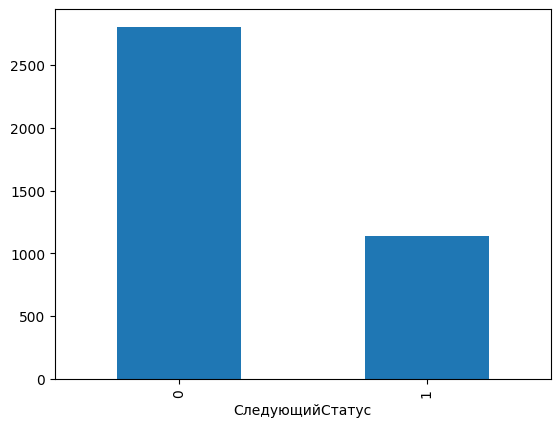

In [366]:
df['СледующийСтатус'].value_counts().plot(kind='bar')

## 8-9. Разбиение на обучающую и тестовую выборки

In [367]:
X = df[[c for c in df.columns if c != 'СледующийСтатус']].values
y = df['СледующийСтатус'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [368]:
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(3152, 30) (3152,)
(789, 30) (789,)


## 10-13. Обучение моделей и оценка качества

Посчитайте показатели качества: «F-мера», точность (Precision) и полнота (Recall)
на обучающей и на тестовой выборках для каждой из моделей.

In [369]:
def evaluate(model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    results = {}
    for name, X, y in [('train', X_train, y_train), ('test', X_test, y_test)]:
        pred = model.predict(X)
        results[name] = {
            'F1': f1_score(y, pred),
            'Precision': precision_score(y, pred),
            'Recall': recall_score(y, pred),
        }
    return results

Из библиотеки sklearn.neighbors возьмите алгоритм классификации KNN
(KNeighborsClassifier). Постройте (обучите) модель. Для параметров используйте
значения по умолчанию.

In [370]:
knn = KNeighborsClassifier()
knn_results = evaluate(knn, X_train, X_test, y_train, y_test)
for split, metrics in knn_results.items():
    print(f'  {split}: {metrics}')

  train: {'F1': 0.7960941987363584, 'Precision': 0.8329326923076923, 'Recall': 0.7623762376237624}
  test: {'F1': 0.6790697674418604, 'Precision': 0.7227722772277227, 'Recall': 0.6403508771929824}


Из библиотеки sklearn.tree возьмите алгоритм классификации на основе деревьев
решений (DecisionTreeClassifier). Постройте (обучите) модель. Для параметров
используйте значения по умолчанию.

In [371]:
dt = DecisionTreeClassifier(random_state=42)
dt_results = evaluate(dt, X_train, X_test, y_train, y_test)
for split, metrics in dt_results.items():
    print(f'  {split}: {metrics}')

  train: {'F1': 0.998898678414097, 'Precision': 1.0, 'Recall': 0.9977997799779978}
  test: {'F1': 0.7297297297297297, 'Precision': 0.75, 'Recall': 0.7105263157894737}


## 14. Выводы
Сделайте вывод о том, насколько хорошо удалось решить задачу
прогнозирования. Какая модель оказалась лучше? Дайте интерпретацию
полученных значений Precision и Recall:
 *Дерево решений по умолчанию склонно к переобучению (высокий train, низкий test), однако лучше работает с нелинейной зависимостью*



* **Precision** — из всех предсказанных «Продана», какая доля действительно стала договором.
* **Recall** — из всех реальных продаж, какую долю модель смогла найти.

## 15. Подбор параметров (доп.)

Выполните подбор параметров для алгоритмов KNN и деревьев решений. Для KNN
попробуйте изменять параметр k – количество соседей, для деревьев решений –
глубину дерева. Постройте графики зависимости показателей качества от
значения параметра (от k в случае KNN и от глубины дерева в случае деревьев
решений). Для параметра k рассматривайте диапазон от 1 до 40. Для глубины
дерева – от 2 до 40. По графикам определите оптимальные значения параметров.

In [372]:
k_range = range(1, 41)
knn_train_f1, knn_test_f1 = [], []

for k in k_range:
    m = KNeighborsClassifier(n_neighbors=k)
    m.fit(X_train, y_train)
    knn_train_f1.append(f1_score(y_train, m.predict(X_train)))
    knn_test_f1.append(f1_score(y_test, m.predict(X_test)))

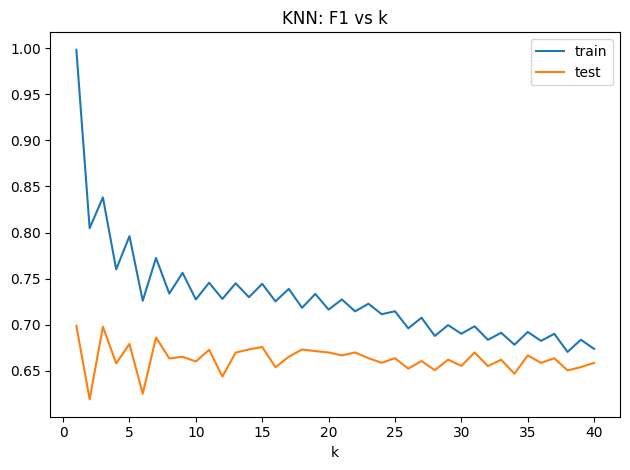

Лучший k=1, F1=0.6987 по сравнению с F1=0.6791


In [373]:
fig, axes = plt.subplots()
axes.plot(list(k_range), knn_train_f1, label='train')
axes.plot(list(k_range), knn_test_f1, label='test')
axes.set_title('KNN: F1 vs k')
axes.set_xlabel('k')
axes.legend()
plt.tight_layout()
plt.show()

best_k = list(k_range)[np.argmax(knn_test_f1)]
print(f'Лучший k={best_k}, F1={max(knn_test_f1):.4f} по сравнению с F1={knn_results["test"]["F1"]:.4f}')

In [374]:
depth_range = range(2, 41)
dt_train_f1, dt_test_f1 = [], []

for d in depth_range:
    m = DecisionTreeClassifier(max_depth=d, random_state=42)
    m.fit(X_train, y_train)
    dt_train_f1.append(f1_score(y_train, m.predict(X_train)))
    dt_test_f1.append(f1_score(y_test, m.predict(X_test)))

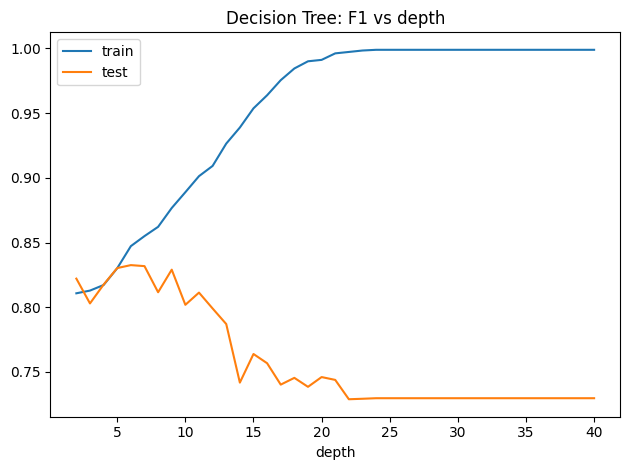

Лучшая depth=6, F1=0.8326 по сравнению с F1=0.7297


In [375]:
fig, axes = plt.subplots()
axes.plot(list(depth_range), dt_train_f1, label='train')
axes.plot(list(depth_range), dt_test_f1, label='test')
axes.set_title('Decision Tree: F1 vs depth')
axes.set_xlabel('depth')
axes.legend()
plt.tight_layout()
plt.show()

best_depth = list(depth_range)[np.argmax(dt_test_f1)]
print(f'Лучшая depth={best_depth}, F1={max(dt_test_f1):.4f} по сравнению с F1={dt_results["test"]["F1"]:.4f}')

## 16. Логистическая регрессия (доп.)

Из библиотеки sklearn.linear_model возьмите алгоритм логистической регрессии
(LogisticRegression). Постройте (обучите) модель. Посчитайте показатели
качества. Сравните результат с другими моделями.

In [376]:
lr = LogisticRegression()
lr_results = evaluate(lr, X_train, X_test, y_train, y_test)

for split, metrics in lr_results.items():
    print(f'  {split}: {metrics}')

  train: {'F1': 0.7622549019607843, 'Precision': 0.8603042876901799, 'Recall': 0.6842684268426843}
  test: {'F1': 0.7506172839506173, 'Precision': 0.8587570621468926, 'Recall': 0.6666666666666666}


## 17. SVM (доп.)

In [377]:
svm = LinearSVC()
svm_results = evaluate(svm, X_train, X_test, y_train, y_test)

for split, metrics in svm_results.items():
    print(f'  {split}: {metrics}')

  train: {'F1': 0.7822435512897421, 'Precision': 0.8601583113456465, 'Recall': 0.7172717271727173}
  test: {'F1': 0.782608695652174, 'Precision': 0.8709677419354839, 'Recall': 0.7105263157894737}


## 18. Выбросы и boxplot (доп.)

In [380]:
df_copy.columns

Index(['ИсточникБрони', 'ВременнаяБронь', 'СледующийСтатус', 'Тип',
       'ПродаваемаяПлощадь', 'Этаж', 'СтоимостьНаДатуБрони', 'ТипСтоимости',
       'ВариантОплаты', 'СкидкаНаКвартиру', 'ФактическаяСтоимостьПомещения',
       'СделкаАН', 'ИнвестиционныйПродукт', 'Привилегия', 'Город_Ижевск',
       'Город_Набережные Челны', 'Город_Пермь', 'Город_Сочи', 'Город_Тверь',
       'Город_Тюмень', 'Город_Уфа', 'Город_Хабаровск', 'Город_Ярославль',
       'Статус лида (из CRM)_F', 'Статус лида (из CRM)_P',
       'Статус лида (из CRM)_S', 'МесяцБрони', 'ДеньНедели', 'ЧасБрони',
       'ЦенаЗаМ2', 'СкидкаВПроцентах'],
      dtype='object')

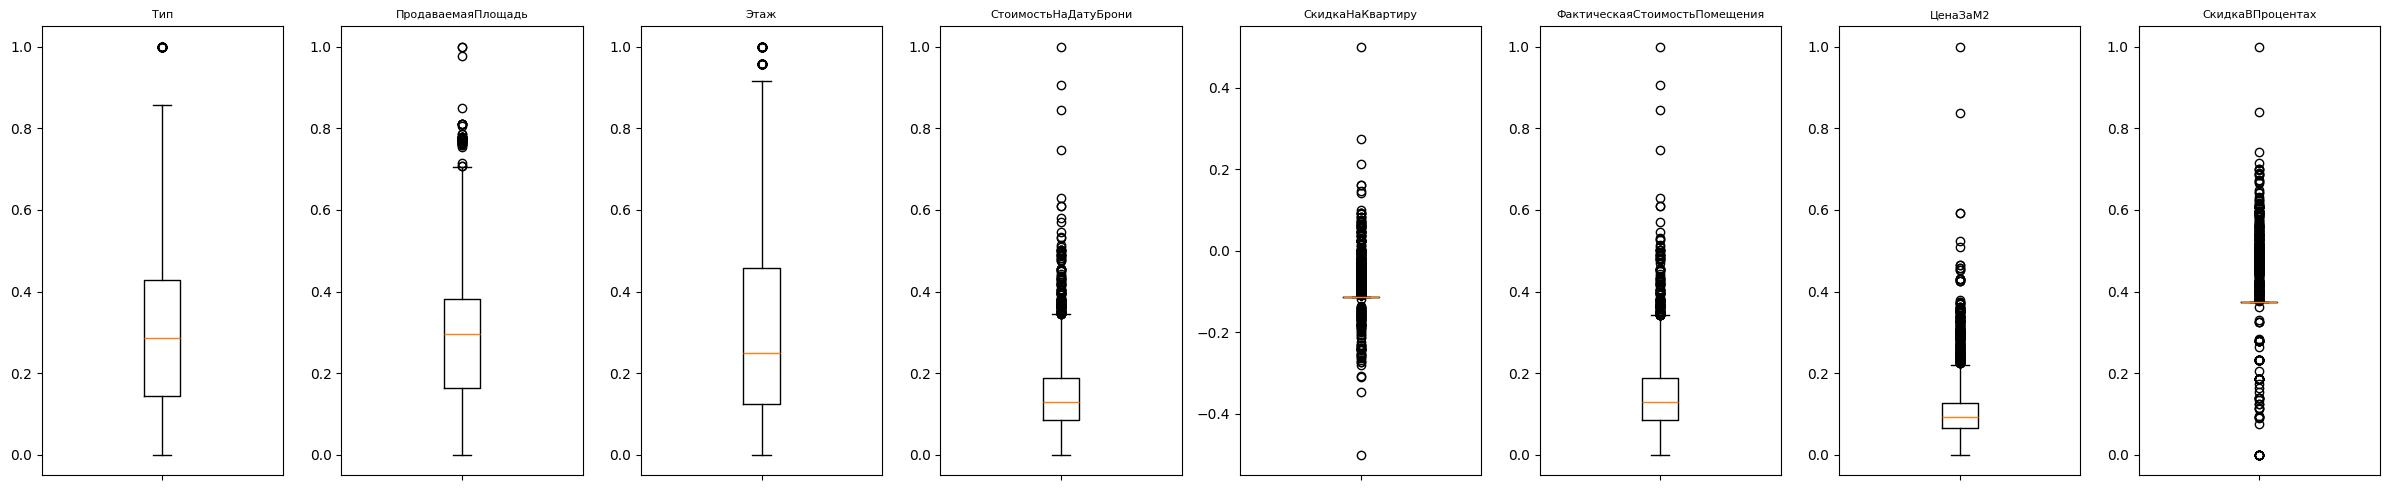

In [ ]:
numeric_cols = ['Тип', 'ПродаваемаяПлощадь', 'Этаж', 'СтоимостьНаДатуБрони',
                'СкидкаНаКвартиру', 'ФактическаяСтоимостьПомещения',
                'ЦенаЗаМ2', 'СкидкаВПроцентах']

fig, axes = plt.subplots(1, len(numeric_cols), figsize=(3 * len(numeric_cols), 5))
for ax, col in zip(axes, numeric_cols):
    ax.boxplot(df_copy[col].dropna())
    ax.set_title(col, fontsize=8)
    ax.tick_params(axis='x', labelbottom=False)
plt.tight_layout()
plt.show()

In [385]:
# Удаление выбросов по IQR для числовых признаков
for col in numeric_cols:
    Q1 = df_copy[col].quantile(0.25)
    Q3 = df_copy[col].quantile(0.75)
    IQR = Q3 - Q1
    df_copy = df_copy[(df_copy[col] >= Q1 - 1.5 * IQR) & (df_copy[col] <= Q3 + 1.5 * IQR)]

print(f'После удаления выбросов: {len(df_copy)} строк (было {len(df)})')

После удаления выбросов: 2949 строк (было 3941)


In [387]:
X2 = df_copy[[c for c in df_copy.columns if c != 'СледующийСтатус']].values
y2 = df_copy['СледующийСтатус'].values
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=42)

In [ ]:
dt2 = DecisionTreeClassifier(max_depth=best_depth, random_state=42)
dt2_results = evaluate(dt2, X2_train, X2_test, y2_train, y2_test)

for split, metrics in dt2_results.items():
    print(f'  {split}: {metrics}')

  train: {'F1': 0.6926994906621392, 'Precision': 0.9807692307692307, 'Recall': 0.5354330708661418}
  test: {'F1': 0.7065868263473054, 'Precision': 1.0, 'Recall': 0.5462962962962963}


In [390]:
for split, metrics in dt_results.items():
    print(f'  {split}: {metrics}')

  train: {'F1': 0.998898678414097, 'Precision': 1.0, 'Recall': 0.9977997799779978}
  test: {'F1': 0.7297297297297297, 'Precision': 0.75, 'Recall': 0.7105263157894737}
